# Praktikum 1

## Teil 1: Datenbeschaffung & Transformation

In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType, TimestampType
import os
import shutil
from pyspark.sql.functions import col, when, count
from pyspark.sql.window import Window
from functools import reduce

# 1. Spark Session erstellen
spark = (SparkSession.builder
    .appName("praktikum")
    .master("local[*]")
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262")
    .config("spark.hadoop.fs.s3a.aws.credentials.provider", "org.apache.hadoop.fs.s3a.AnonymousAWSCredentialsProvider")
    .config("spark.hadoop.fs.s3a.endpoint", "s3.amazonaws.com")
    .config("spark.hadoop.fs.s3a.connection.timeout", "60000")
    .config("spark.hadoop.fs.s3a.connection.establish.timeout", "30000")
    .config("spark.hadoop.fs.s3a.threads.keepalivetime", "60")
    .config("spark.hadoop.fs.s3a.multipart.purge.age", "86400")
    .getOrCreate())

final = False
# OpenAQ Location_Id : City
# 2162185 : Ingolstadt
# 2669 München Stachus
# 3117 Vohburg
# 2162591 Paris
# Berlin 2993

# Schema Definition, Umwandlung relevanter Spalten (Timestamp, Numerisch)
schema = StructType([
    StructField("location_id", IntegerType(), True),
    StructField("sensors_id", IntegerType(), True),
    StructField("location", StringType(), True),
    StructField("datetime", TimestampType(), True),
    StructField("lat", DoubleType(), True),
    StructField("lon", DoubleType(), True),
    StructField("parameter", StringType(), True),
    StructField("units", StringType(), True),
    StructField("value", DoubleType(), True),

])

df1 = spark.read.schema(schema).option("header", "true").option("timestampFormat", "yyyy-MM-dd'T'HH:mm:ssXXX").option("encoding", "UTF-8").csv("s3a://openaq-data-archive/records/csv.gz/locationid=2162185/year=2025/") #ingolstadt25
df2 = spark.read.schema(schema).option("header", "true").option("timestampFormat", "yyyy-MM-dd'T'HH:mm:ssXXX").option("encoding", "UTF-8").csv("s3a://openaq-data-archive/records/csv.gz/locationid=2669/year=2020/") #münchenStachus20

df3 = spark.read.schema(schema).option("header", "true").option("timestampFormat", "yyyy-MM-dd'T'HH:mm:ssXXX").option("encoding", "UTF-8").csv("s3a://openaq-data-archive/records/csv.gz/locationid=2162185/year=2026/")
df4 = spark.read.schema(schema).option("header", "true").option("timestampFormat", "yyyy-MM-dd'T'HH:mm:ssXXX").option("encoding", "UTF-8").csv("s3a://openaq-data-archive/records/csv.gz/locationid=2162185/year=2024/") #ingo 24, 26

df5 = spark.read.schema(schema).option("header", "true").option("timestampFormat", "yyyy-MM-dd'T'HH:mm:ssXXX").option("encoding", "UTF-8").csv("s3a://openaq-data-archive/records/csv.gz/locationid=2669/year=2021/")
df6 = spark.read.schema(schema).option("header", "true").option("timestampFormat", "yyyy-MM-dd'T'HH:mm:ssXXX").option("encoding", "UTF-8").csv("s3a://openaq-data-archive/records/csv.gz/locationid=2669/year=2022/")
df7 = spark.read.schema(schema).option("header", "true").option("timestampFormat", "yyyy-MM-dd'T'HH:mm:ssXXX").option("encoding", "UTF-8").csv("s3a://openaq-data-archive/records/csv.gz/locationid=2669/year=2023/")
df8 = spark.read.schema(schema).option("header", "true").option("timestampFormat", "yyyy-MM-dd'T'HH:mm:ssXXX").option("encoding", "UTF-8").csv("s3a://openaq-data-archive/records/csv.gz/locationid=2669/year=2024/")
df9 = spark.read.schema(schema).option("header", "true").option("timestampFormat", "yyyy-MM-dd'T'HH:mm:ssXXX").option("encoding", "UTF-8").csv("s3a://openaq-data-archive/records/csv.gz/locationid=2669/year=2025/") #muc 21-25
df10 = spark.read.schema(schema).option("header", "true").option("timestampFormat", "yyyy-MM-dd'T'HH:mm:ssXXX").option("encoding", "UTF-8").csv("s3a://openaq-data-archive/records/csv.gz/locationid=3117/year=2025/") #vohburg
df11 = spark.read.schema(schema).option("header", "true").option("timestampFormat", "yyyy-MM-dd'T'HH:mm:ssXXX").option("encoding", "UTF-8").csv("s3a://openaq-data-archive/records/csv.gz/locationid=2993/year=2025/") #berlin25
df12 = spark.read.schema(schema).option("header", "true").option("timestampFormat", "yyyy-MM-dd'T'HH:mm:ssXXX").option("encoding", "UTF-8").csv("s3a://openaq-data-archive/records/csv.gz/locationid=2162591/year=2025/") #paris25

df = df1.unionByName(df2).unionByName(df3).unionByName(df4).unionByName(df5).unionByName(df6).unionByName(df7).unionByName(df8).unionByName(df9).unionByName(df10).unionByName(df11).unionByName(df12)

print("Spark Dataframe Schema: \n")
df.printSchema()

print("Anzahl Werte:")
print(df.count())
df.show(5, truncate=False)

# Behandlung fehlende Werte / Ausreißer
print("\n Missing Values / Outliers")
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()
# Interpretation: Missing Values fehlen schon im CSV, wie z.B. fehlender Dezember München 2020


# Ausreißer entfernen durch IQR
filtered_dfs = []

for param in ["pm25", "pm10", "no2", "o3", "no"]:
    df_param = df.filter(col("parameter") == param)
    
    quantiles = df_param.approxQuantile("value", [0.25, 0.75], 0.01)
    q1, q3 = quantiles
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    df_param_filtered = df_param.filter((col("value") >= lower) & (col("value") <= upper))
    
    filtered_dfs.append(df_param_filtered)

df = reduce(lambda a, b: a.unionByName(b), filtered_dfs)

print("Anzahl bleibender Werte: ") 
print(df.count())

# Parquet jedes mal schreiben dauert lange, schreibe es nur wenn final
if final: 
    if "data.parquet" in os.listdir("."):
        shutil.rmtree("data.parquet")
        
    df.write.parquet("data.parquet")
    print("Parquet File geschrieben.")


Spark Dataframe Schema: 

root
 |-- location_id: integer (nullable = true)
 |-- sensors_id: integer (nullable = true)
 |-- location: string (nullable = true)
 |-- datetime: timestamp (nullable = true)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- parameter: string (nullable = true)
 |-- units: string (nullable = true)
 |-- value: double (nullable = true)
 |-- month: integer (nullable = true)

Anzahl Werte:
252732
+-----------+----------+---------------------------------+-------------------+-----------------+------------------+---------+-----+-----+-----+
|location_id|sensors_id|location                         |datetime           |lat              |lon               |parameter|units|value|month|
+-----------+----------+---------------------------------+-------------------+-----------------+------------------+---------+-----+-----+-----+
|2162185    |7773219   |Ingolstadt/Münchener Str.-2132151|2025-03-09 00:00:00|48.74261999970499|11.434639999960496|pm10   

## Wie entwickelt sich der Feinstaub Wert (pm10) für Ingolstadt in 2024 und 2025? 

In [3]:
from pyspark.sql.functions import year, month
from pyspark.sql.functions import to_date, avg
import matplotlib.pyplot as plt

# Nur Ingolstadt, 2024 & 2025, nur pm10 herausgefiltert
df_2025_2024_pm10 = df.filter(
    (df.location_id == 2162185) &
    (df.parameter == "pm10") &
    (year(df.datetime).isin([2024, 2025]))
)

print(df_2025_2024_pm10.count())
df_2025_2024_pm10.show(5)

13359
+-----------+----------+--------------------+-------------------+-----------------+------------------+---------+-----+-----+-----+
|location_id|sensors_id|            location|           datetime|              lat|               lon|parameter|units|value|month|
+-----------+----------+--------------------+-------------------+-----------------+------------------+---------+-----+-----+-----+
|    2162185|   7773219|Ingolstadt/Münche...|2025-03-09 08:00:00|48.74261999970499|11.434639999960496|     pm10|µg/m³|34.95|    3|
|    2162185|   7773219|Ingolstadt/Münche...|2025-03-09 09:00:00|48.74261999970499|11.434639999960496|     pm10|µg/m³|31.39|    3|
|    2162185|   7773219|Ingolstadt/Münche...|2025-03-09 10:00:00|48.74261999970499|11.434639999960496|     pm10|µg/m³|30.56|    3|
|    2162185|   7773219|Ingolstadt/Münche...|2025-03-09 11:00:00|48.74261999970499|11.434639999960496|     pm10|µg/m³|29.39|    3|
|    2162185|   7773219|Ingolstadt/Münche...|2025-03-09 12:00:00|48.742619999

In [4]:
# Gruppiere nach Jahr & Monat
df_monthly = df_2025_2024_pm10.groupBy(
    year("datetime").alias("year"),
    "month"
).agg(
    avg("value").alias("pm10_avg")
).orderBy("year", "month")



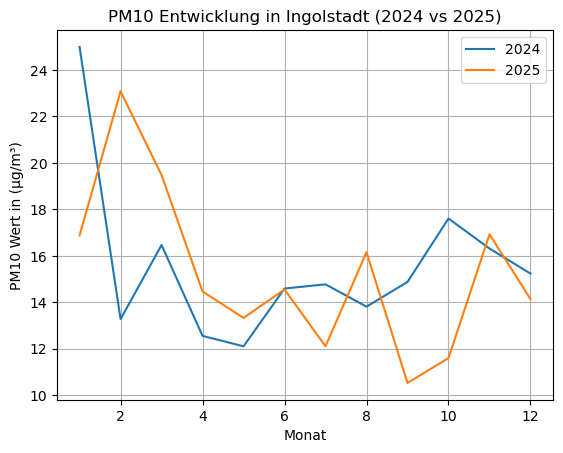

In [5]:
# Plotte Daten
pandas_df = df_monthly.toPandas()

for year in pandas_df["year"].unique():
    subset = pandas_df[pandas_df["year"] == year]
    plt.plot(subset["month"], subset["pm10_avg"], label=str(year))

plt.title("PM10 Entwicklung in Ingolstadt (2024 vs 2025)")
plt.xlabel("Monat")
plt.ylabel("PM10 Wert in (µg/m³)")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
#Interpretation der Ergebnisse:

## Wie verändert sich der PM2.5 Wert (Feinstaub < 2.5 µm) in München von 2020 bis 2025?

In [31]:
# Nur München, 2020-2025, nur pm2,5 herausgefiltert
from pyspark.sql.functions import year, month
from pyspark.sql.functions import to_date, avg
import matplotlib.pyplot as plt

df_muc_pm25 = df.filter(
    (df.location_id == 2669) &
    (df.parameter == "pm25") &
    (year(df.datetime).isin([2020, 2021, 2022, 2023, 2024, 2025])))

print(df_muc_pm25.count())
df_muc_pm25.show(5)

20335
+-----------+----------+------------+-------------------+---------+---------+---------+-----+-----+-----+
|location_id|sensors_id|    location|           datetime|      lat|      lon|parameter|units|value|month|
+-----------+----------+------------+-------------------+---------+---------+---------+-----+-----+-----+
|       2669|      6688|DEBY037-2669|2021-07-15 00:00:00|48.137252|11.564924|     pm25|µg/m³| 3.51|    7|
|       2669|      6688|DEBY037-2669|2021-07-15 01:00:00|48.137252|11.564924|     pm25|µg/m³| 2.84|    7|
|       2669|      6688|DEBY037-2669|2021-07-15 02:00:00|48.137252|11.564924|     pm25|µg/m³| 1.31|    7|
|       2669|      6688|DEBY037-2669|2021-07-15 03:00:00|48.137252|11.564924|     pm25|µg/m³| 1.26|    7|
|       2669|      6688|DEBY037-2669|2021-07-15 04:00:00|48.137252|11.564924|     pm25|µg/m³| 2.09|    7|
+-----------+----------+------------+-------------------+---------+---------+---------+-----+-----+-----+
only showing top 5 rows


In [32]:
df_pm25_trend = df_muc_pm25.groupBy(year("datetime").alias("year")) \
    .agg(avg("value").alias("avg_pm25")) \
    .orderBy("year")

df_pm25_trend.show()

+----+------------------+
|year|          avg_pm25|
+----+------------------+
|2021|10.004590909090908|
|2022|  9.47168699186992|
|2023|  8.88574894320897|
|2024| 9.030212014134273|
|2025|10.013375821816723|
+----+------------------+



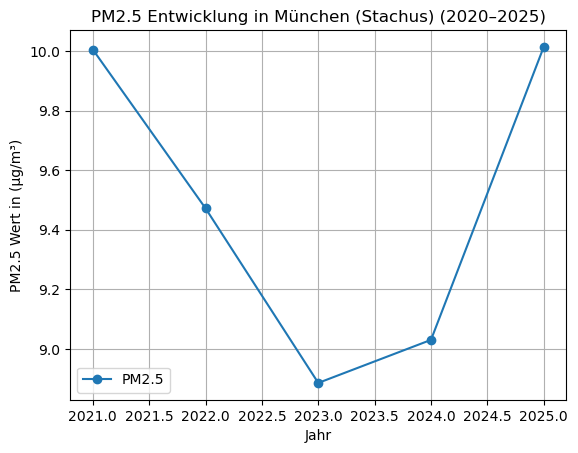

In [33]:
pandas_df = df_pm25_trend.toPandas()

plt.plot(pandas_df["year"], pandas_df["avg_pm25"], marker="o", label="PM2.5")
plt.title("PM2.5 Entwicklung in München (Stachus) (2020–2025)")
plt.xlabel("Jahr")
plt.ylabel("PM2.5 Wert in (µg/m³)")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
#Interpretation der Ergebnisse: 

##  Wie unterschied sich der Ozon Wert O₃ zwischen einer Großstadt wie Berlin zu einer Kleinstadt wie Vohburg in 2025?

In [11]:
df_ber_o3_25 = df.filter(
    (df.location_id == 2993) &
    (df.parameter == "o3") &
    (year(df.datetime) == 2025))

print("Anzahl Werte in Berlin:")
print(df_ber_o3_25.count())
df_ber_o3_25.show(5)


df_voh_o3_25 = df.filter(
    (df.location_id == 3117) &
    (df.parameter == "o3") &
    (year(df.datetime) == 2025))

print("Anzahl Werte in Vohburg:")
print(df_voh_o3_25.count())
df_voh_o3_25.show(5)



Anzahl Werte in Berlin:
7923
+-----------+----------+--------------------+-------------------+-----------------+------------------+---------+-----+-----+-----+
|location_id|sensors_id|            location|           datetime|              lat|               lon|parameter|units|value|month|
+-----------+----------+--------------------+-------------------+-----------------+------------------+---------+-----+-----+-----+
|       2993|      6353|Berlin Neukölln-2993|2025-03-10 00:00:00|52.48945100006434|13.430843999965024|       o3|µg/m³| 3.01|    3|
|       2993|      6353|Berlin Neukölln-2993|2025-03-10 01:00:00|52.48945100006434|13.430843999965024|       o3|µg/m³| 2.54|    3|
|       2993|      6353|Berlin Neukölln-2993|2025-03-10 02:00:00|52.48945100006434|13.430843999965024|       o3|µg/m³| 1.98|    3|
|       2993|      6353|Berlin Neukölln-2993|2025-03-10 03:00:00|52.48945100006434|13.430843999965024|       o3|µg/m³| 1.45|    3|
|       2993|      6353|Berlin Neukölln-2993|2025-03-1

In [12]:
#nach Monaten gruppieren

df_berlin_monthly = df_ber_o3_25.groupBy(
    month("datetime").alias("month")
).agg(
    avg("value").alias("o3_avg")
).orderBy("month")

df_vohburg_monthly = df_voh_o3_25.groupBy(
    month("datetime").alias("month")
).agg(
    avg("value").alias("o3_avg")
).orderBy("month")

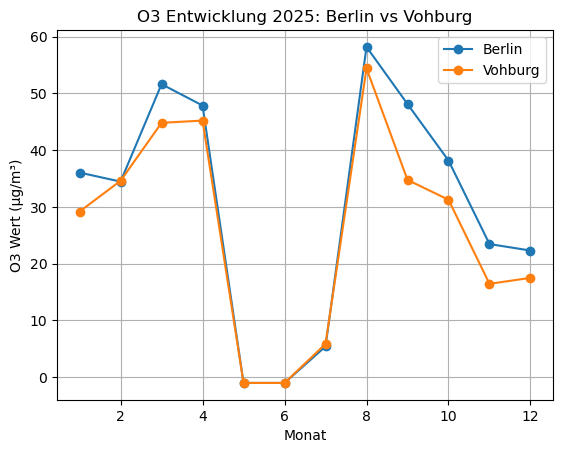

In [13]:
#plot

p_berlin = df_berlin_monthly.toPandas()
p_vohburg = df_vohburg_monthly.toPandas()

plt.plot(p_berlin["month"], p_berlin["o3_avg"], marker="o", label="Berlin")
plt.plot(p_vohburg["month"], p_vohburg["o3_avg"], marker="o", label="Vohburg")

plt.title("O3 Entwicklung 2025: Berlin vs Vohburg")
plt.xlabel("Monat")
plt.ylabel("O3 Wert (µg/m³)")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
#Interpretation der Ergebnisse: 

##  Wie verhielt sich der Stickstoffdioxid Wert NO₂ von Berlin, DEU zu Paris, FRA im Jahr 2025?

In [15]:
df_ber_no2_25 = df.filter(
    (df.location_id == 2993) &
    (df.parameter == "no2") &
    (year(df.datetime) == 2025))

print("Anzahl Werte in Berlin:")
print(df_ber_no2_25.count())
df_ber_no2_25.show(5)


df_paris_no2_25 = df.filter(
    (df.location_id == 2162591) &
    (df.parameter == "o3") &
    (year(df.datetime) == 2025))

print("Anzahl Werte in Vohburg:")
print(df_paris_no2_25.count())
df_paris_no2_25.show(5)

Anzahl Werte in Berlin:
7787
+-----------+----------+--------------------+-------------------+-----------------+------------------+---------+-----+-----+-----+
|location_id|sensors_id|            location|           datetime|              lat|               lon|parameter|units|value|month|
+-----------+----------+--------------------+-------------------+-----------------+------------------+---------+-----+-----+-----+
|       2993|      6352|Berlin Neukölln-2993|2025-03-10 11:00:00|52.48945100006434|13.430843999965024|      no2|µg/m³|41.94|    3|
|       2993|      6352|Berlin Neukölln-2993|2025-03-10 12:00:00|52.48945100006434|13.430843999965024|      no2|µg/m³|38.49|    3|
|       2993|      6352|Berlin Neukölln-2993|2025-03-10 13:00:00|52.48945100006434|13.430843999965024|      no2|µg/m³|26.48|    3|
|       2993|      6352|Berlin Neukölln-2993|2025-03-10 14:00:00|52.48945100006434|13.430843999965024|      no2|µg/m³|16.03|    3|
|       2993|      6352|Berlin Neukölln-2993|2025-03-1

In [16]:
#nach Monaten gruppieren

df_berlin_monthly = df_ber_no2_25.groupBy(
    month("datetime").alias("month")
).agg(
    avg("value").alias("no2_avg")
).orderBy("month")

df_paris_monthly = df_paris_no2_25.groupBy(
    month("datetime").alias("month")
).agg(
    avg("value").alias("no2_avg")
).orderBy("month")

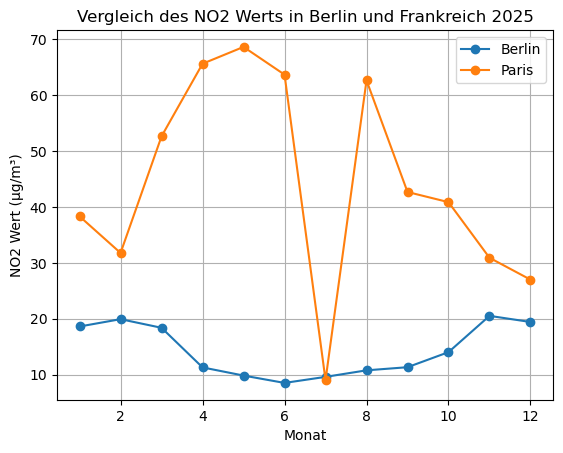

In [17]:
#plot

p_berlin = df_berlin_monthly.toPandas()
p_paris = df_paris_monthly.toPandas()

plt.plot(p_berlin["month"], p_berlin["no2_avg"], marker="o", label="Berlin")
plt.plot(p_paris["month"], p_paris["no2_avg"], marker="o", label="Paris")

plt.title("Vergleich des NO2 Werts in Berlin und Frankreich 2025")
plt.xlabel("Monat")
plt.ylabel("NO2 Wert (µg/m³)")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
#Interpretation der Ergebnisse:

## Teil 3: Machine Learning mit Spark MLLib

### Vorhersage der pm2.5 Werte in 2025 durch vorherige Daten ab 2021-2024 in München

In [37]:
from pyspark.sql.functions import hour, dayofweek, month
from pyspark.sql.window import Window
from pyspark.sql.functions import lag
from pyspark.ml.regression import LinearRegression
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import RegressionEvaluator

# Nutze den Dataframe von München 2020-2025 weiter als spark_ml_data
print(df_muc_pm25.count())
df_muc_pm25.show(5)

# Value wird zum Ground Truth Label, füge Datum als eigene Spalten hinzu
spark_ml_data = df_muc_pm25.withColumnRenamed("value", "label")
spark_ml_data = spark_ml_data.orderBy("datetime")

spark_ml_data = spark_ml_data.withColumn("hour", hour("datetime"))
spark_ml_data = spark_ml_data.withColumn("dayofweek", dayofweek("datetime"))
spark_ml_data = spark_ml_data.withColumn("month", month("datetime"))
spark_ml_data.show(5)


# Nimm mit lag(...) den Wert im 1. Zeitschritt zuvor, 2 Zeitschritte  zuvor, 3 Schritte zuvor, ...
window = Window.orderBy("datetime")
spark_ml_data = spark_ml_data.withColumn("lag1", lag("label", 1).over(window))
spark_ml_data = spark_ml_data.withColumn("lag2", lag("label", 2).over(window))
spark_ml_data = spark_ml_data.withColumn("lag3", lag("label", 3).over(window))

spark_ml_data = spark_ml_data.dropna()


assembler = VectorAssembler(
    inputCols=["lag1", "lag2", "lag3", "hour", "dayofweek", "month"],
    outputCol="features"
)

features = assembler.transform(spark_ml_data)

train = features.filter(features.datetime < "2025-01-01")
test = features.filter(features.datetime >= "2025-01-01")

print("Train Dataframe: " + str(train.count()))
print("Test Dataframe: " + str(test.count()))

linearregression = LinearRegression(featuresCol="features", labelCol="label")
model = linearregression.fit(train)

predictions = model.transform(test)
predictions.select("datetime", "label", "prediction").show()


20335
+-----------+----------+------------+-------------------+---------+---------+---------+-----+-----+-----+
|location_id|sensors_id|    location|           datetime|      lat|      lon|parameter|units|value|month|
+-----------+----------+------------+-------------------+---------+---------+---------+-----+-----+-----+
|       2669|      6688|DEBY037-2669|2021-07-15 00:00:00|48.137252|11.564924|     pm25|µg/m³| 3.51|    7|
|       2669|      6688|DEBY037-2669|2021-07-15 01:00:00|48.137252|11.564924|     pm25|µg/m³| 2.84|    7|
|       2669|      6688|DEBY037-2669|2021-07-15 02:00:00|48.137252|11.564924|     pm25|µg/m³| 1.31|    7|
|       2669|      6688|DEBY037-2669|2021-07-15 03:00:00|48.137252|11.564924|     pm25|µg/m³| 1.26|    7|
|       2669|      6688|DEBY037-2669|2021-07-15 04:00:00|48.137252|11.564924|     pm25|µg/m³| 2.09|    7|
+-----------+----------+------------+-------------------+---------+---------+---------+-----+-----+-----+
only showing top 5 rows
+-----------+---

RMSE: 1.993100961123523


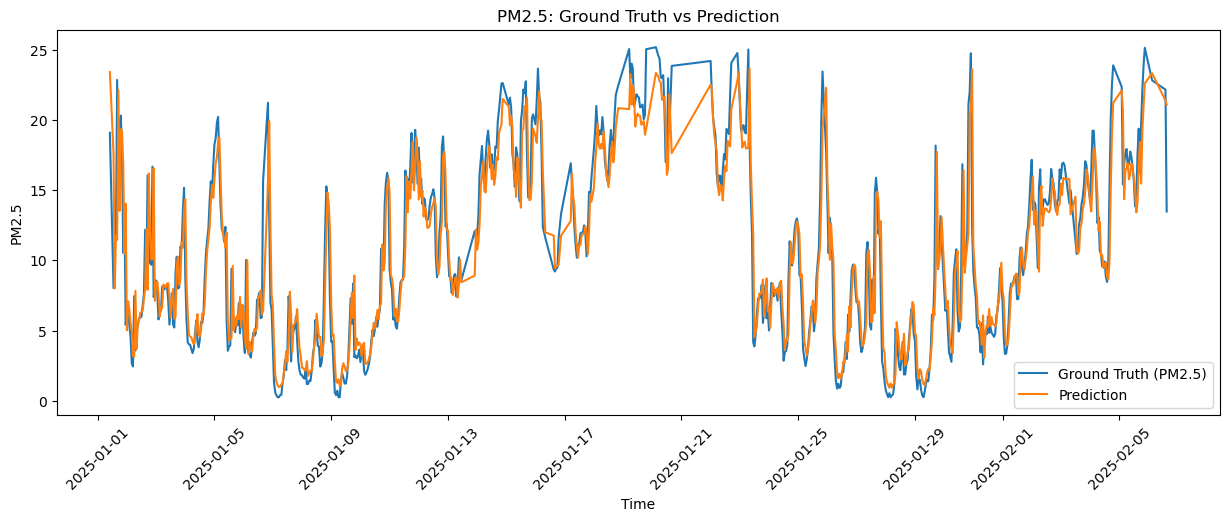

In [38]:
from pyspark.ml.evaluation import RegressionEvaluator
import matplotlib.pyplot as plt


# Evaluation durch RMSE & Visualisierung von Predictions vs. Ground Truth
rmse_evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
rmse = rmse_evaluator.evaluate(predictions)
print("RMSE:", rmse)

# Plotte die ersten 750 Predictions (24*31), ca. 1 Monat an Predictions
plot_df = predictions.select("datetime", "label", "prediction").orderBy("datetime") 
pdf = plot_df.toPandas()
pdf = pdf.head(750)


plt.figure(figsize=(15,5))

plt.plot(pdf["datetime"], pdf["label"], label="Ground Truth (PM2.5)")
plt.plot(pdf["datetime"], pdf["prediction"], label="Prediction")

plt.xlabel("Time")
plt.ylabel("PM2.5")
plt.title("PM2.5: Ground Truth vs Prediction")
plt.legend()
plt.xticks(rotation=45)

plt.show()